There are 0 duplicate values
There are 0 missing values
Total missing values per column:
road_number    964488
dtype: int64
Total number of missing values (including special values): 964488
eventid                   0
event_start               0
event_end                 0
duration_seconds          0
latitude                  0
longitude                 0
speed_kmh                 0
end_speed_kmh             0
maxwaarde                 0
category                  0
incident_severity         0
is_valid                  0
road_segment_id           0
road_manager_type         0
road_number          964488
road_name                 0
place_name                0
municipality_name         0
road_manager_name         0
dtype: int64

Starting Cleaning:

eventid              0
event_start          0
event_end            0
duration_seconds     0
latitude             0
longitude            0
speed_kmh            0
end_speed_kmh        0
maxwaarde            0
category             0
incident_sever

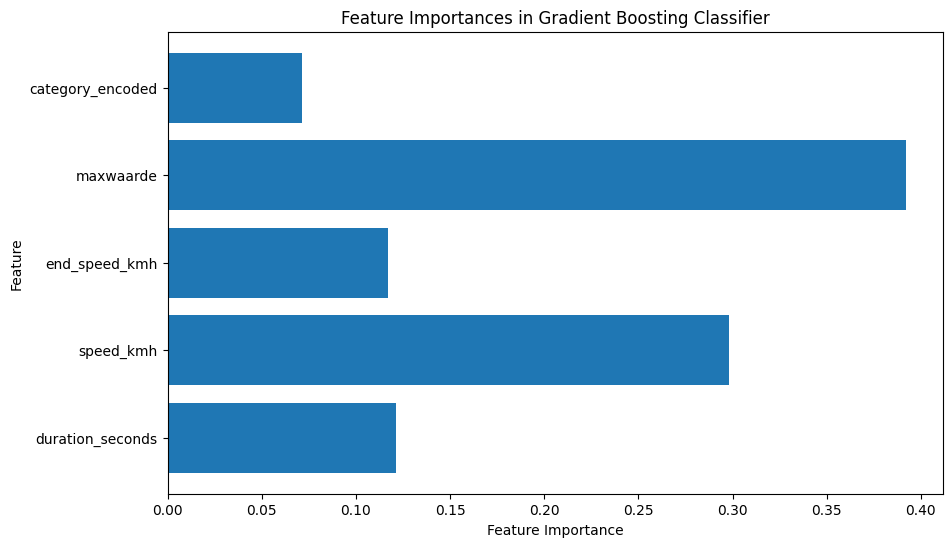

In [1]:
# GradientBoostingClassifier, model 2

# importing all the required libraries
import psycopg2
from sqlalchemy import create_engine, Column, Integer, String
from sqlalchemy.ext.declarative import declarative_base
from sqlalchemy.orm import sessionmaker
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# defining again the database parameters
db_params = {
    "host": "194.171.191.226",
    "port": "6379",
    "database": "postgres",
    "user": "group2",
    "password": "blockd_2024group2_58",
}

# creating a connection string
conn_string = f"postgresql+psycopg2://{db_params['user']}:{db_params['password']}@{db_params['host']}:{db_params['port']}/{db_params['database']}"

# creating an SQLAlchemy engine
engine = create_engine(conn_string)

# pandas to execute a query and load data into a DataFrame
query = "SELECT * FROM data_lake.safe_driving"
df_safe_driving = pd.read_sql(query, engine)

# clsoing the connection
engine.dispose()

# ensuing 'event_start' and 'event_end' are in datetime format
df_safe_driving["event_start"] = pd.to_datetime(df_safe_driving["event_start"])
df_safe_driving["event_end"] = pd.to_datetime(df_safe_driving["event_end"])

# checking for duplicate values
dup_count = df_safe_driving.duplicated().sum()
print("There are", dup_count, "duplicate values")

# one more chcking for missing values in different forms
missing_count = df_safe_driving.isnull().sum().sum()
print("There are", missing_count, "missing values")

# setting the future option to opt-in to the new behavior
pd.set_option("future.no_silent_downcasting", True)

# replcing empty strings with NaN in the 'road_number' column
df_safe_driving["road_number"] = df_safe_driving["road_number"].replace("", np.nan)

# verifying that the replacement has been done
missing_values_count = df_safe_driving.isnull().sum()
print("Total missing values per column:")
print(missing_values_count[missing_values_count > 0])

# summarizing all findings
total_missing = missing_values_count.sum()
print(f"Total number of missing values (including special values): {total_missing}")

# veryfying the rows with missing values
print(df_safe_driving.isna().sum())

# start cleaning
print("\nStarting Cleaning:\n")

# removing the 'road_number' column
df_safe_driving = df_safe_driving.drop("road_number", axis=1)

# veryfying that the rows with missing 'road_number' values have been removed
print(df_safe_driving.isna().sum())

# strping whitespace from the 'category' column
df_safe_driving["category"] = df_safe_driving["category"].str.strip()

# unique values
print(df_safe_driving["category"].unique())

# checking for duplicate values
dup_count = df_safe_driving.duplicated().sum()
print("After cleaning there are", dup_count, "duplicate values")

# checking one more time for missing values in different forms
missing_count = df_safe_driving.isnull().sum().sum()
print("After cleaning there are", missing_count, "missing values")

# initializing LabelEncoder
label_encoder = LabelEncoder()

# encoding the 'category' column
df_safe_driving["category_encoded"] = label_encoder.fit_transform(
    df_safe_driving["category"]
)

# strpping whitespace from the 'category' column
df_safe_driving["incident_severity"] = df_safe_driving["incident_severity"].str.strip()

# printing the unique values
print(df_safe_driving["incident_severity"].unique())


def classify_incident_severity_corrected(severity):
    low = ["HA1", "HB1", "HC1", "SP1"]
    medium = [
        "HC4",
        "HC13",
        "HA2",
        "HB2",
        "HC2",
        "HC5",
        "HC7",
        "HC14",
        "HC16",
        "SP2",
        "SP3",
    ]
    high = [
        "HA3",
        "HB3",
        "HC3",
        "HC9",
        "HC11",
        "HC12",
        "HC15",
        "HC17",
        "HC18",
        "HC19",
        "HC20",
        "HC21",
        "HC6",
        "HC8",
        "HC10",
        "SP4",
        "SP5",
    ]
    if severity in low:
        return "Low"
    elif severity in medium:
        return "Medium"
    elif severity in high:
        return "High"
    else:
        return "Unknown"


# corrected classification function
df_safe_driving["incident_severity_bin"] = df_safe_driving["incident_severity"].apply(
    classify_incident_severity_corrected
)

# updated DataFrame
df_safe_driving.head()

# Step 1: prepraring the data
X = df_safe_driving[
    ["duration_seconds", "speed_kmh", "end_speed_kmh", "maxwaarde", "category_encoded"]
]  # Features
y = df_safe_driving["incident_severity_bin"]

# Step 2: splitting the data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# initializing StandardScaler
scaler = StandardScaler()

# Fitting scaler to training data and transform both training and testing data
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Initializing GradientBoostingClassifier
gbc = GradientBoostingClassifier(random_state=42)

# Training the model
gbc.fit(X_train_scaled, y_train)

# making predictions
y_pred = gbc.predict(X_test_scaled)

# evaluating the model withh all metrics such as accuracy; precision, recall and f1-score
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.2f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

# Plotting feature importances
plt.figure(figsize=(10, 6))
plt.barh(X.columns, gbc.feature_importances_)
plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("Feature Importances in Gradient Boosting Classifier")
plt.show()

Here is the GridSearch: 

In [2]:
from sklearn.model_selection import GridSearchCV

# spliting the training data into training and validation sets
X_train_final, X_val, y_train_final, y_val = train_test_split(X_train_scaled, y_train, test_size=0.2, random_state=42)

#defining the hyperparameters grid to search
param_dist = {
    'n_estimators': [100, 150],
    'learning_rate': [0.1, 0.2, 0.5],
    'max_depth': [3, 4, 5, 6]
}

# initializing the Gradient Boosting model
model = GradientBoostingClassifier(random_state=42)

# initializing the GridSearchCV
grid_search = GridSearchCV(model, param_dist, cv=3, scoring='accuracy')

# Grid Search
grid_search.fit(X_train_final, y_train_final)

#best model from the grid search 
best_model = grid_search.best_estimator_

# evaluation of the best model on the validation set
val_accuracy = accuracy_score(y_val, best_model.predict(X_val))
print("Validation Accuracy:", val_accuracy)

# ecaluatiion of the best model on the test set
test_accuracy = accuracy_score(y_test, best_model.predict(X_test_scaled))
print("Test Accuracy:", test_accuracy)

KeyboardInterrupt: 